**DRIVING BEHAVIOR CLUSTERING ANALYSIS**

Unsupervised Clustering to Identify Driver Behavior Profiles
Project: Driving Assessment Model with CDTA

**CONTEXT:**
 - Unsupervised task: No labeled "cautious" vs "dangerous" driving
 - Feature-blind approach: Using all numeric features without domain interpretation
 - Goal: Group driving behaviors into distinct clusters/profiles
 - Complementary to anomaly detection

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ============================================================================
# 1. DATA LOADING & INITIAL EXPLORATION
# ============================================================================

print("="*80)
print("CLUSTERING ANALYSIS: DRIVER BEHAVIOR PROFILING")
print("="*80)
print("Objective: Group driving patterns into distinct behavioral profiles")
print("Approach: Hierarchical, K-means, DBSCAN (Course Methodologies)")
print("Data: Unlabeled, feature-blind heuristic tuning")
print("="*80)

df = pd.read_csv("cleaned_data.csv")

print(f"\nDataset Shape: {df.shape}")
print(f"Total Time Windows: {df.shape[0]}")
print(f"Features Available: {df.shape[1]}")



CLUSTERING ANALYSIS: DRIVER BEHAVIOR PROFILING
Objective: Group driving patterns into distinct behavioral profiles
Approach: Hierarchical, K-means, DBSCAN (Course Methodologies)
Data: Unlabeled, feature-blind heuristic tuning

Dataset Shape: (94380, 31)
Total Time Windows: 94380
Features Available: 31


## 2. FEATURE SELECTION & PREPROCESSING (FEATURE-BLIND)

In [10]:

print("\n" + "="*80)
print("FEATURE PREPROCESSING")
print("="*80)

# Exclude metadata columns only - treat all others as generic numeric features
# NOT use driver_id as ground truth (unsupervised task)
metadata_cols = ['driver_id', 'pathorder', 'time_s']
feature_cols = [col for col in df.columns if col not in metadata_cols]

print(f"\nTotal features for clustering: {len(feature_cols)}")
print(f"Note: Using feature-blind approach (no domain interpretation)")

# Create feature matrix
X = df[feature_cols].copy()

# Check data quality
print(f"\nMissing values: {X.isnull().sum().sum()}")
if X.isnull().sum().sum() > 0:
    print("Warning: Missing values detected. Handling via forward fill...")
    X = X.fillna(method='ffill').fillna(method='bfill')

print(f"\nFeature ranges (before scaling):")
print(X.describe().loc[['min', 'max']].T.head(10))

# Standardization (critical for distance-based clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nScaled data shape: {X_scaled.shape}")
print(f"Scaled mean (should be ~0): {X_scaled.mean():.6f}")
print(f"Scaled std (should be ~1): {X_scaled.std():.6f}")





FEATURE PREPROCESSING

Total features for clustering: 28
Note: Using feature-blind approach (no domain interpretation)

Missing values: 0

Feature ranges (before scaling):
                                             min      max
fuel_consumption                             0.0  10931.2
accelerator_pedal_value                      0.0     99.2
throttle_position_signal                     0.0    100.0
intake_air_pressure                          0.0    178.0
absolute_throttle_position                  12.5     84.3
engine_in_fuel_cut_off                       0.0      1.0
engine_speed                                 0.0   6253.0
engine_torque_after_correction               0.0     83.6
torque_of_friction                           0.0     28.1
flywheel_torque_after_torque_interventions -47.5    158.9

Scaled data shape: (94380, 28)
Scaled mean (should be ~0): -0.000000
Scaled std (should be ~1): 1.000000


## 3. DIMENSIONALITY REDUCTION FOR VISUALIZATION


PCA FOR VISUALIZATION
Variance explained by PC1: 38.07%
Variance explained by PC2: 20.48%
Total variance (2 components): 58.55%


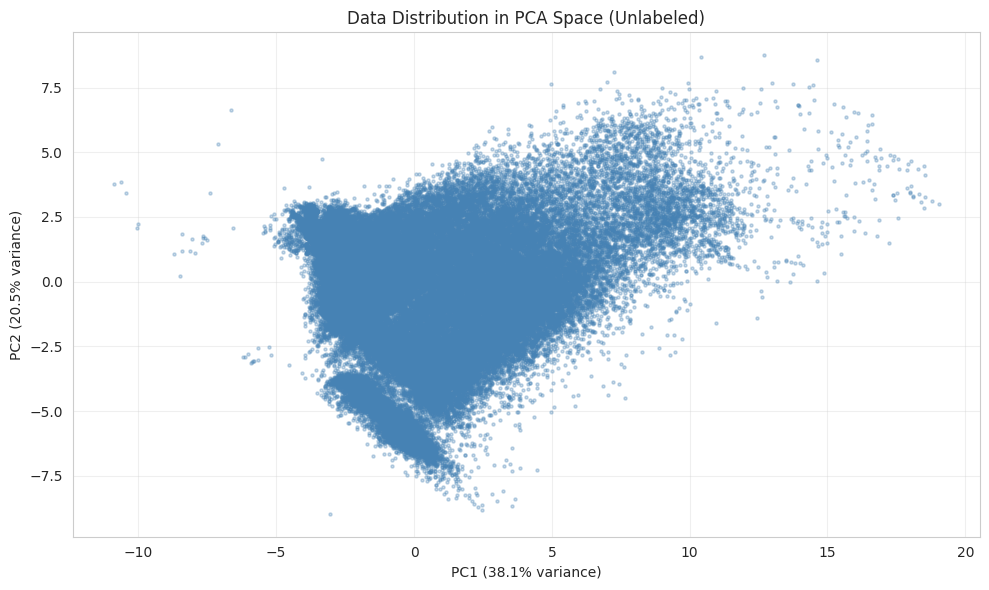

In [11]:

print("\n" + "="*80)
print("PCA FOR VISUALIZATION")
print("="*80)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance (2 components): {pca.explained_variance_ratio_.sum():.2%}")

# Visualize data distribution (no labels, just raw data)
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=5, c='steelblue')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Data Distribution in PCA Space (Unlabeled)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. HIERARCHICAL CLUSTERING


HIERARCHICAL CLUSTERING

Using sample size: 5000 (computational efficiency)

Computing linkage matrices...
  - SINGLE linkage...
  - COMPLETE linkage...
  - AVERAGE linkage...


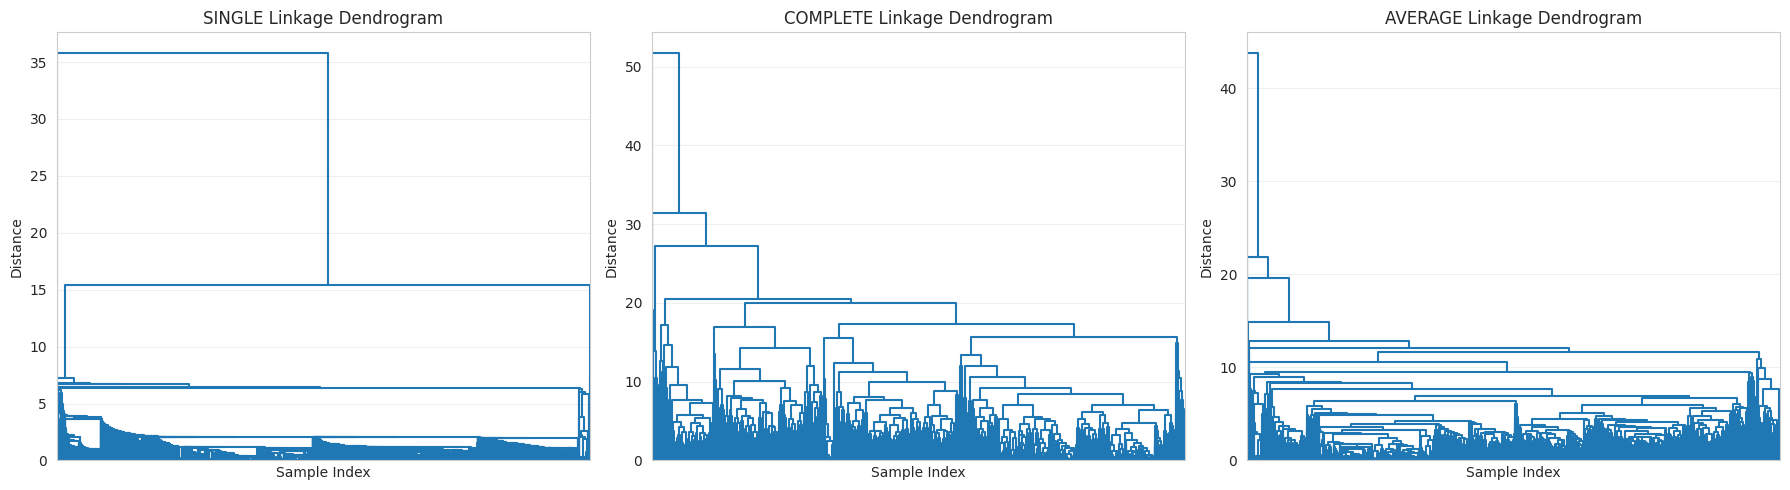


Evaluating hierarchical clustering for k in [2, 3, 4, 5, 6, 8, 10]...

Best hierarchical configuration:
  Method: SINGLE
  k: 2
  Silhouette: 0.844
  Calinski-Harabasz: 68.32
  Davies-Bouldin: 0.112

Distance Matrix Sample (first 10 samples):
      S0    S1    S2    S3    S4    S5    S6    S7    S8    S9
S0  0.00  6.79  8.00  5.14  2.98  3.48  7.97  8.57  8.54  9.86
S1  6.79  0.00  7.37  3.36  4.75  5.20  7.32  5.98  5.95  8.77
S2  8.00  7.37  0.00  7.98  7.63  8.10  0.15  3.44  3.30  7.58
S3  5.14  3.36  7.98  0.00  3.20  4.34  7.94  7.47  7.48  9.09
S4  2.98  4.75  7.63  3.20  0.00  3.20  7.57  7.44  7.45  9.04
S5  3.48  5.20  8.10  4.34  3.20  0.00  8.08  8.33  8.22  9.91
S6  7.97  7.32  0.15  7.94  7.57  8.08  0.00  3.35  3.22  7.56
S7  8.57  5.98  3.44  7.47  7.44  8.33  3.35  0.00  0.63  7.35
S8  8.54  5.95  3.30  7.48  7.45  8.22  3.22  0.63  0.00  7.13
S9  9.86  8.77  7.58  9.09  9.04  9.91  7.56  7.35  7.13  0.00

Note: Values show Euclidean distances between samples
      Lo

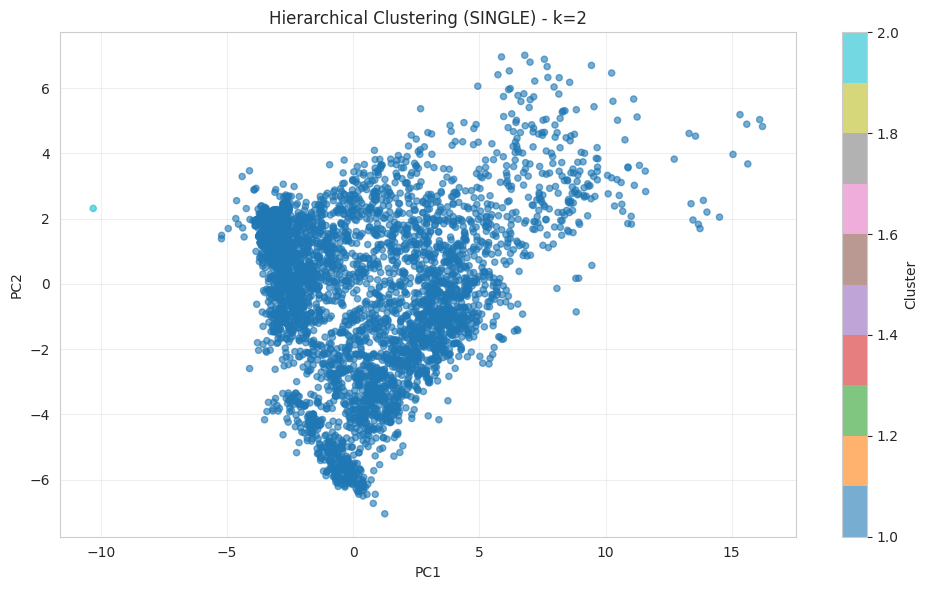


Cluster Prototypes (Hierarchical - SINGLE):

Cluster 1 (n=4999 samples):
  Top 5 feature values: [0.007 0.009 0.002 0.005 0.003]

Cluster 2 (n=1 samples):
  Top 5 feature values: [-0.66  -0.391 -0.488 -0.046 -0.495]

Full centroid table shape: (2, 28)
(Showing first 5 features × all clusters)
   fuel_consumption  accelerator_pedal_value  throttle_position_signal  \
0             0.007                    0.009                     0.002   
1            -0.660                   -0.391                    -0.488   

   intake_air_pressure  absolute_throttle_position  
0                0.005                       0.003  
1               -0.046                      -0.495  


In [4]:

print("\n" + "="*80)
print("HIERARCHICAL CLUSTERING")
print("="*80)

# Sample data for computational efficiency (hierarchical is O(n²))
sample_size = min(5000, len(X_scaled))  # Use up to 5000 samples
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=sample_size, replace=False)
X_sample = X_scaled[sample_idx]
X_pca_sample = X_pca[sample_idx]

print(f"\nUsing sample size: {sample_size} (computational efficiency)")

# Compute linkage for different methods
methods = ['single', 'complete', 'average']
linkage_results = {}

print("\nComputing linkage matrices...")
for method in methods:
    print(f"  - {method.upper()} linkage...")
    Z = linkage(X_sample, method=method, metric='euclidean')
    linkage_results[method] = Z

# Plot dendrograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, method in enumerate(methods):
    dendrogram(linkage_results[method], ax=axes[idx], no_labels=True, color_threshold=0)
    axes[idx].set_title(f'{method.upper()} Linkage Dendrogram')
    axes[idx].set_xlabel('Sample Index')
    axes[idx].set_ylabel('Distance')
    axes[idx].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Try different k values for hierarchical clustering
k_range_hier = [2, 3, 4, 5, 6, 8, 10]
hier_results = {}

print(f"\nEvaluating hierarchical clustering for k in {k_range_hier}...")
for method in methods:
    hier_results[method] = {}
    for k in k_range_hier:
        clusters = fcluster(linkage_results[method], k, criterion='maxclust')
        sil = silhouette_score(X_sample, clusters)
        ch = calinski_harabasz_score(X_sample, clusters)
        db = davies_bouldin_score(X_sample, clusters)

        hier_results[method][k] = {
            'clusters': clusters,
            'silhouette': sil,
            'calinski_harabasz': ch,
            'davies_bouldin': db
        }

# Find best configuration (maximize silhouette)
best_hier_config = max(
    [(method, k, hier_results[method][k]['silhouette'])
     for method in methods for k in k_range_hier],
    key=lambda x: x[2]
)
best_method, best_k_hier, best_sil_hier = best_hier_config

print(f"\nBest hierarchical configuration:")
print(f"  Method: {best_method.upper()}")
print(f"  k: {best_k_hier}")
print(f"  Silhouette: {best_sil_hier:.3f}")
print(f"  Calinski-Harabasz: {hier_results[best_method][best_k_hier]['calinski_harabasz']:.2f}")
print(f"  Davies-Bouldin: {hier_results[best_method][best_k_hier]['davies_bouldin']:.3f}")

# Display distance matrix for small sample (lab-style demonstration)
print(f"\nDistance Matrix Sample (first 10 samples):")
print("="*60)
dist_sample = pdist(X_sample[:10], metric='euclidean')
dist_matrix = squareform(dist_sample)
dist_df = pd.DataFrame(dist_matrix,
                       columns=[f'S{i}' for i in range(10)],
                       index=[f'S{i}' for i in range(10)])
print(dist_df.round(2))
print("\nNote: Values show Euclidean distances between samples")
print("      Lower values = more similar driving behavior")

# Visualize best hierarchical result
plt.figure(figsize=(10, 6))
best_clusters = hier_results[best_method][best_k_hier]['clusters']
scatter = plt.scatter(X_pca_sample[:, 0], X_pca_sample[:, 1],
                     c=best_clusters, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Hierarchical Clustering ({best_method.upper()}) - k={best_k_hier}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cluster prototypes (centroids in original feature space)
print(f"\nCluster Prototypes (Hierarchical - {best_method.upper()}):")
print("="*60)
hier_centroids = []
for cluster_id in range(1, best_k_hier + 1):
    cluster_mask = best_clusters == cluster_id
    centroid = X_sample[cluster_mask].mean(axis=0)
    hier_centroids.append(centroid)
    print(f"\nCluster {cluster_id} (n={cluster_mask.sum()} samples):")
    print(f"  Top 5 feature values: {centroid[:5].round(3)}")

hier_centroids_df = pd.DataFrame(hier_centroids, columns=feature_cols)
print(f"\nFull centroid table shape: {hier_centroids_df.shape}")
print("(Showing first 5 features × all clusters)")
print(hier_centroids_df.iloc[:, :5].round(3))


## 5. K-MEANS CLUSTERING


K-MEANS CLUSTERING

Computing metrics for k in [2, 15]...


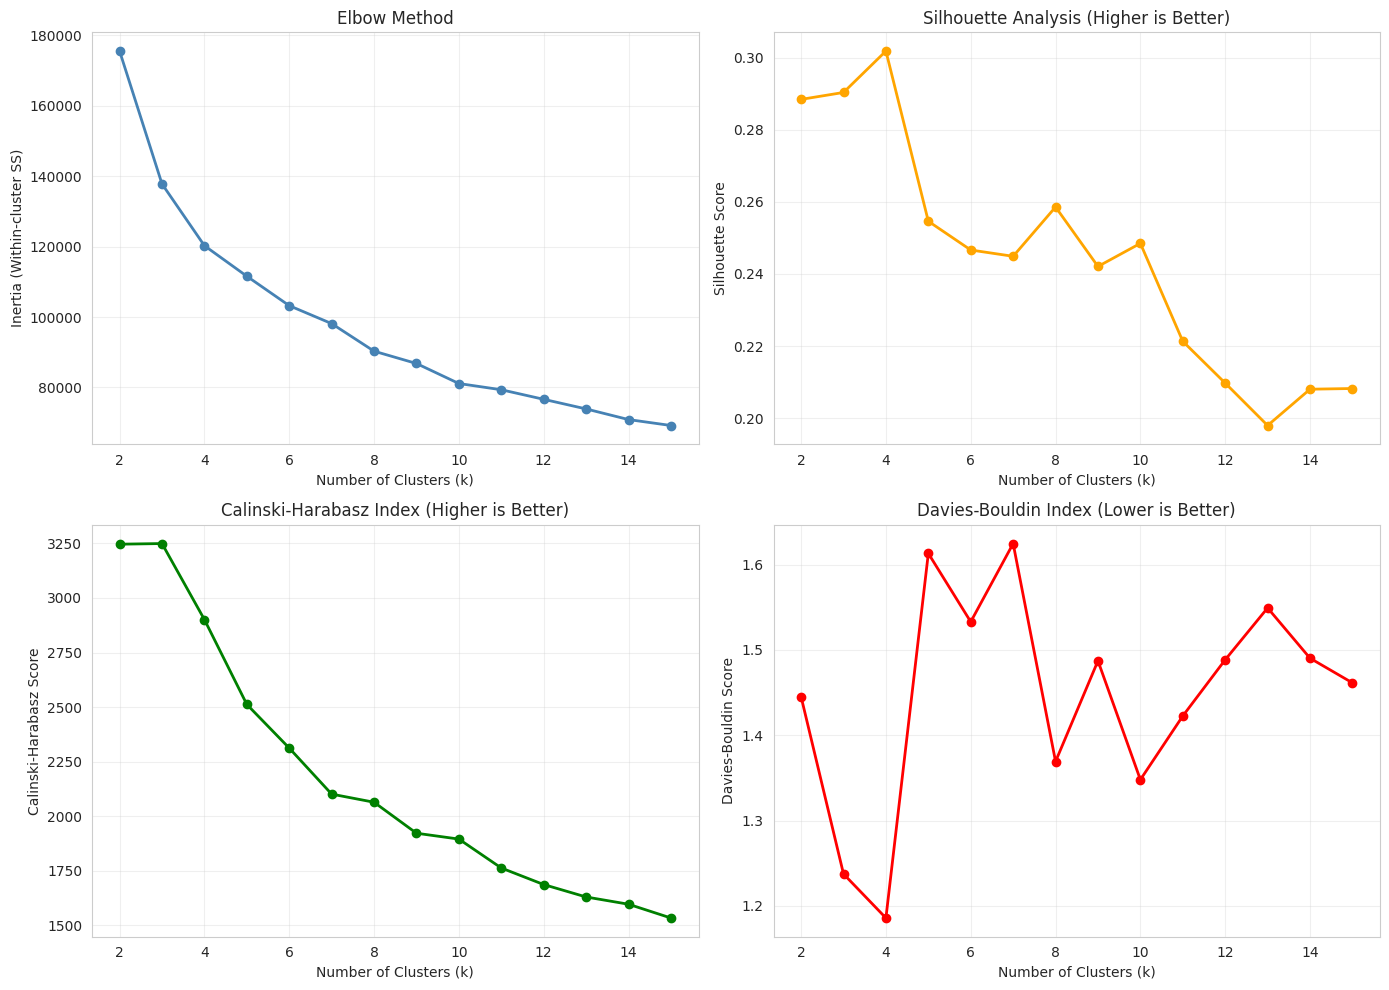


Optimal k based on Silhouette Score: 4
  Silhouette: 0.302
  Calinski-Harabasz: 2900.91
  Davies-Bouldin: 1.186

Cluster distribution:
  Cluster 0: 4072 samples (47.2%)
  Cluster 1: 430 samples (5.0%)
  Cluster 2: 2330 samples (27.0%)
  Cluster 3: 1797 samples (20.8%)


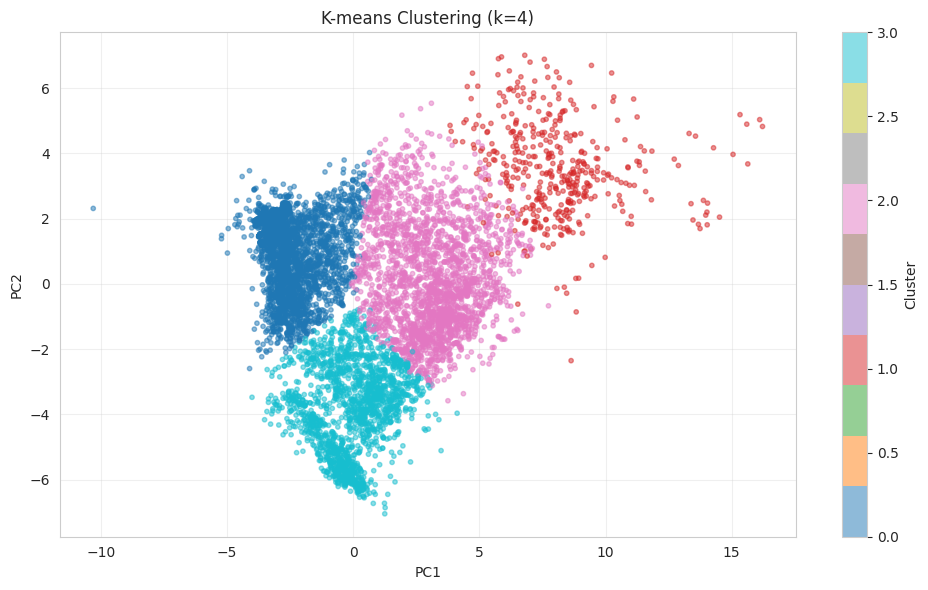


Cluster Centroids (K-means):
Centroid table shape: (4, 28)

Showing first 5 features for each cluster:
   fuel_consumption  accelerator_pedal_value  throttle_position_signal  \
0            -0.523                   -0.357                    -0.385   
1             2.941                    2.507                     4.001   
2             0.758                    0.367                     0.192   
3            -0.500                   -0.267                    -0.333   

   intake_air_pressure  absolute_throttle_position  
0               -0.350                      -0.388  
1                1.988                       3.995  
2                0.688                       0.195  
3               -0.574                      -0.329  

Cluster interpretation (based on centroid patterns):
  Cluster 0: 4072 samples (47.2%)
    Dominant features: ['wheel_velocity_front_left_hand', 'vehicle_speed', 'wheel_velocity_rear_left_hand']
  Cluster 1: 430 samples (5.0%)
    Dominant features: ['throttl

In [5]:

print("\n" + "="*80)
print("K-MEANS CLUSTERING")
print("="*80)

# Elbow method + silhouette analysis
k_range = range(2, 16)
inertias = []
silhouettes = []
ch_scores = []
db_scores = []

print("\nComputing metrics for k in [2, 15]...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

# Plot evaluation metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(k_range, inertias, marker='o', linewidth=2, color='steelblue')
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('Inertia (Within-cluster SS)')
axes[0, 0].set_title('Elbow Method')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(k_range, silhouettes, marker='o', linewidth=2, color='orange')
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_title('Silhouette Analysis (Higher is Better)')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(k_range, ch_scores, marker='o', linewidth=2, color='green')
axes[1, 0].set_xlabel('Number of Clusters (k)')
axes[1, 0].set_ylabel('Calinski-Harabasz Score')
axes[1, 0].set_title('Calinski-Harabasz Index (Higher is Better)')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(k_range, db_scores, marker='o', linewidth=2, color='red')
axes[1, 1].set_xlabel('Number of Clusters (k)')
axes[1, 1].set_ylabel('Davies-Bouldin Score')
axes[1, 1].set_title('Davies-Bouldin Index (Lower is Better)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Select optimal k based on silhouette score
optimal_k = k_range[np.argmax(silhouettes)]
print(f"\nOptimal k based on Silhouette Score: {optimal_k}")
print(f"  Silhouette: {max(silhouettes):.3f}")
print(f"  Calinski-Harabasz: {ch_scores[optimal_k-2]:.2f}")
print(f"  Davies-Bouldin: {db_scores[optimal_k-2]:.3f}")

# Fit optimal k-means
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_optimal.fit_predict(X_scaled)

# Cluster distribution
print(f"\nCluster distribution:")
unique, counts = np.unique(kmeans_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} samples ({count/len(kmeans_labels)*100:.1f}%)")

# Visualize k-means clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=kmeans_labels, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-means Clustering (k={optimal_k})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cluster centroids (lab-style prototype table)
print(f"\nCluster Centroids (K-means):")
print("="*60)
kmeans_centroids = kmeans_optimal.cluster_centers_
centroids_df = pd.DataFrame(kmeans_centroids, columns=feature_cols)

print(f"Centroid table shape: {centroids_df.shape}")
print("\nShowing first 5 features for each cluster:")
print(centroids_df.iloc[:, :5].round(3))

print("\nCluster interpretation (based on centroid patterns):")
for i in range(optimal_k):
    cluster_size = (kmeans_labels == i).sum()
    print(f"  Cluster {i}: {cluster_size} samples ({cluster_size/len(kmeans_labels)*100:.1f}%)")
    # Show top 3 features with highest absolute values (scaled)
    top_features_idx = np.argsort(np.abs(kmeans_centroids[i]))[-3:][::-1]
    print(f"    Dominant features: {[feature_cols[idx] for idx in top_features_idx]}")


## 6. DBSCAN CLUSTERING


DBSCAN CLUSTERING

Computing 4-nearest neighbors distances...


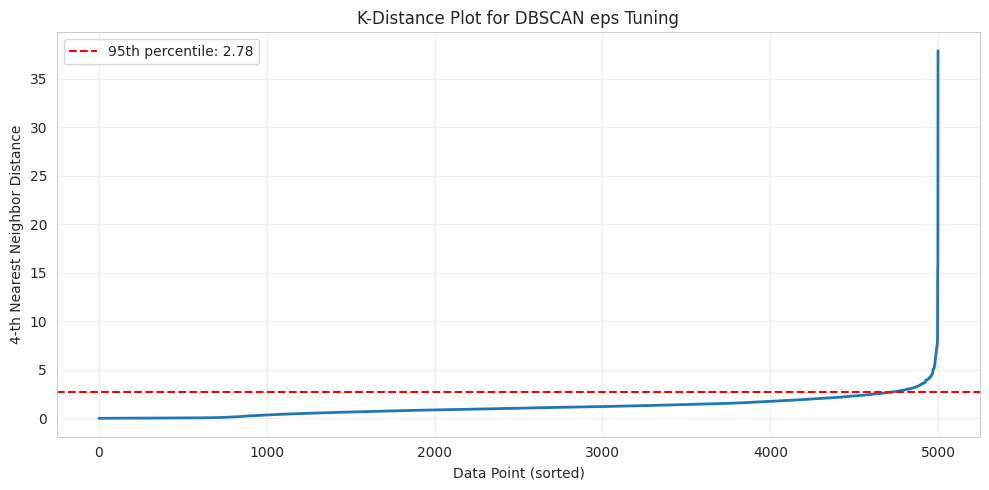


Candidate eps values: [np.float64(1.18), np.float64(2.27), np.float64(2.32), np.float64(2.78), np.float64(3.52)]

Testing DBSCAN configurations...

DBSCAN Results:
eps      min_samp   clusters   noise%     silhouette  
------------------------------------------------------------
1.18     3          166        22.9       -0.091      
1.18     5          75         30.4       -0.023      
1.18     10         33         40.6       0.084       
2.27     3          32         4.0        -0.000      
2.27     5          18         5.5        0.041       
2.27     10         11         8.2        0.105       
2.32     3          31         3.7        -0.032      
2.32     5          19         5.1        0.057       
2.32     10         11         7.6        0.104       
2.78     3          21         1.7        0.124       
2.78     5          11         2.4        0.159       
2.78     10         9          3.9        0.199       
3.52     3          10         0.9        0.151       
3.52

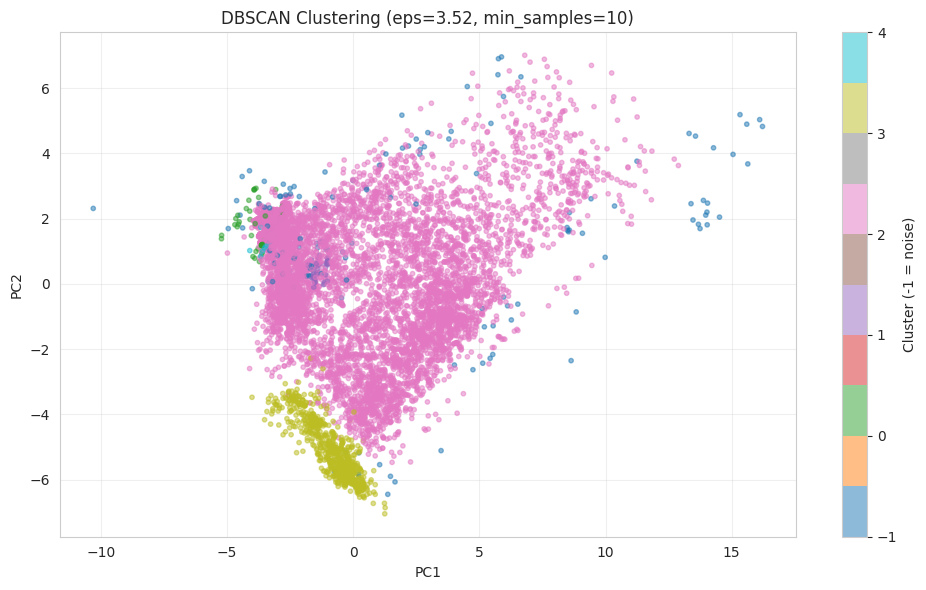

In [6]:

print("\n" + "="*80)
print("DBSCAN CLUSTERING")
print("="*80)

# k-distance plot for eps tuning
from sklearn.neighbors import NearestNeighbors

k_neighbors = 4  # min_samples = k + 1 ≈ 5
print(f"\nComputing {k_neighbors}-nearest neighbors distances...")

nbrs = NearestNeighbors(n_neighbors=k_neighbors).fit(X_sample)
distances, indices = nbrs.kneighbors(X_sample)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(distances, linewidth=2)
plt.xlabel('Data Point (sorted)')
plt.ylabel(f'{k_neighbors}-th Nearest Neighbor Distance')
plt.title('K-Distance Plot for DBSCAN eps Tuning')
plt.grid(True, alpha=0.3)
plt.axhline(y=np.percentile(distances, 95), color='r', linestyle='--',
            label=f'95th percentile: {np.percentile(distances, 95):.2f}')
plt.legend()
plt.tight_layout()
plt.show()

# Suggest eps range
eps_candidates = [
    np.percentile(distances, 90),
    np.percentile(distances, 95),
    np.percentile(distances, 98),
    distances.mean(),
    distances.mean() + distances.std()
]
eps_candidates = sorted(set(np.round(eps_candidates, 2)))

print(f"\nCandidate eps values: {eps_candidates}")

# Try multiple configurations
min_samples_range = [3, 5, 10]
dbscan_results = {}

print(f"\nTesting DBSCAN configurations...")
for eps in eps_candidates:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # Silhouette only if valid clustering
        if n_clusters > 1 and n_noise < len(labels) * 0.9:
            mask = labels != -1
            sil = silhouette_score(X_scaled[mask], labels[mask])
        else:
            sil = -1

        config_key = (eps, min_samples)
        dbscan_results[config_key] = {
            'labels': labels,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_pct': n_noise/len(labels)*100,
            'silhouette': sil
        }

# Display results
print("\nDBSCAN Results:")
print(f"{'eps':<8} {'min_samp':<10} {'clusters':<10} {'noise%':<10} {'silhouette':<12}")
print("-" * 60)
for (eps, min_samp), res in sorted(dbscan_results.items()):
    print(f"{eps:<8.2f} {min_samp:<10} {res['n_clusters']:<10} "
          f"{res['noise_pct']:<10.1f} {res['silhouette']:<12.3f}")

# Select best configuration
# Selection criteria: Maximize silhouette score while keeping noise < 50%
# This balances cluster quality with maintaining meaningful cluster assignments
valid_configs = {k: v for k, v in dbscan_results.items()
                 if v['silhouette'] > 0 and v['noise_pct'] < 50}

if valid_configs:
    best_dbscan_config = max(valid_configs.items(), key=lambda x: x[1]['silhouette'])
    best_eps, best_min_samp = best_dbscan_config[0]
    best_dbscan_res = best_dbscan_config[1]

    print(f"\nBest DBSCAN configuration:")
    print(f"  (Chosen based on highest silhouette with < 50% noise)")
    print(f"  eps: {best_eps:.2f}")
    print(f"  min_samples: {best_min_samp}")
    print(f"  Clusters: {best_dbscan_res['n_clusters']}")
    print(f"  Noise: {best_dbscan_res['noise_pct']:.1f}%")
    print(f"  Silhouette: {best_dbscan_res['silhouette']:.3f}")

    # Cluster prototypes for DBSCAN (non-noise points only)
    print(f"\nCluster Prototypes (DBSCAN):")
    print("="*60)
    dbscan_labels = best_dbscan_res['labels']
    for cluster_id in range(best_dbscan_res['n_clusters']):
        cluster_mask = dbscan_labels == cluster_id
        cluster_size = cluster_mask.sum()
        if cluster_size > 0:
            centroid = X_scaled[cluster_mask].mean(axis=0)
            print(f"\nCluster {cluster_id} (n={cluster_size} samples):")
            print(f"  Top 5 feature values: {centroid[:5].round(3)}")

    noise_count = (dbscan_labels == -1).sum()
    print(f"\nNoise points: {noise_count} ({noise_count/len(dbscan_labels)*100:.1f}%)")
    print("  → Points that don't fit any dense cluster pattern")

    # Visualize
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                         c=best_dbscan_res['labels'], cmap='tab10', alpha=0.5, s=10)
    plt.colorbar(scatter, label='Cluster (-1 = noise)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'DBSCAN Clustering (eps={best_eps:.2f}, min_samples={best_min_samp})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\nWarning: No valid DBSCAN configuration found.")
    print("Data may not have clear density-based structure.")


## 7. COMPARATIVE ANALYSIS

In [7]:

print("\n" + "="*80)
print("COMPARATIVE SUMMARY")
print("="*80)

# Create comparison table
comparison_data = {
    'Method': [
        f'Hierarchical ({best_method})',
        f'K-means',
        f'DBSCAN' if valid_configs else 'DBSCAN (failed)'
    ],
    'Optimal k/config': [
        f'k={best_k_hier}',
        f'k={optimal_k}',
        f'eps={best_eps:.2f}, ms={best_min_samp}' if valid_configs else 'N/A'
    ],
    'Silhouette Score': [
        f'{best_sil_hier:.3f}',
        f'{max(silhouettes):.3f}',
        f'{best_dbscan_res["silhouette"]:.3f}' if valid_configs else 'N/A'
    ],
    'Number of Clusters': [
        best_k_hier,
        optimal_k,
        best_dbscan_res['n_clusters'] if valid_configs else 'N/A'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))



COMPARATIVE SUMMARY

                Method Optimal k/config Silhouette Score  Number of Clusters
Hierarchical (single)              k=2            0.844                   2
              K-means              k=4            0.302                   4
               DBSCAN  eps=3.52, ms=10            0.201                   5


## 8. INTERPRETATION & RECOMMENDATIONS

In [8]:

print("\n" + "="*80)
print("INTERPRETATION & RECOMMENDATIONS")
print("="*80)

print(f"""
1. CLUSTER STRUCTURE FOUND:
   - Best performing method: {"K-means" if max(silhouettes) > best_sil_hier else f"Hierarchical ({best_method})"}
   - Optimal number of clusters: {optimal_k if max(silhouettes) > best_sil_hier else best_k_hier}
   - Silhouette score: {max(max(silhouettes), best_sil_hier):.3f}
     → {'Good' if max(max(silhouettes), best_sil_hier) > 0.5 else 'Moderate' if max(max(silhouettes), best_sil_hier) > 0.3 else 'Weak'} cluster separation

2. BEHAVIOR PROFILE INTERPRETATION (Feature-Blind):
   - Each cluster represents a distinct driving behavior profile
   - Cluster sizes indicate prevalence of each driving style
   - Cannot label as "cautious" vs "dangerous" without domain validation
   - Recommend: Cross-reference with anomaly detection results

3. METHODOLOGICAL NOTES:
   - All features treated equally (no domain weighting)
   - Results depend on feature scaling and distance metric (Euclidean)
   - No external validation possible (unsupervised task)
   - Internal metrics (Silhouette, CH, DB) guide cluster quality

4. NEXT STEPS FOR INTEGRATION:
   - Compare clustering results with anomaly detection outputs
   - Investigate: Do outliers fall into specific clusters?
   - Consider: Are small clusters potential "dangerous driving" groups?
   - Validate: Domain expert review of cluster characteristics

5. PRACTICAL USAGE:
   - Assign new time windows to nearest cluster centroid (K-means)
   - Flag windows that are far from all centroids as potential anomalies
   - Combine with anomaly scores for robust assessment
""")

print("="*80)
print("CLUSTERING ANALYSIS COMPLETE")
print("="*80)


INTERPRETATION & RECOMMENDATIONS

1. CLUSTER STRUCTURE FOUND:
   - Best performing method: Hierarchical (single)
   - Optimal number of clusters: 2
   - Silhouette score: 0.844
     → Good cluster separation

2. BEHAVIOR PROFILE INTERPRETATION (Feature-Blind):
   - Each cluster represents a distinct driving behavior profile
   - Cluster sizes indicate prevalence of each driving style
   - Cannot label as "cautious" vs "dangerous" without domain validation
   - Recommend: Cross-reference with anomaly detection results

3. METHODOLOGICAL NOTES:
   - All features treated equally (no domain weighting)
   - Results depend on feature scaling and distance metric (Euclidean)
   - No external validation possible (unsupervised task)
   - Internal metrics (Silhouette, CH, DB) guide cluster quality

4. NEXT STEPS FOR INTEGRATION:
   - Compare clustering results with anomaly detection outputs
   - Investigate: Do outliers fall into specific clusters?
   - Consider: Are small clusters potential "da